<a href="https://colab.research.google.com/github/Janitha-Umeshan/Statistical-Learning-e23381/blob/main/Assignment%231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

# A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


### Part 1: Point uniformly distributed with respect to area

In [3]:
import math

r = 10  #Radius of the disk

# Total area of the disk
total_area = math.pi * (r**2)

# Area of the event A: point lies within 1 unit of the boundary
area_of_event_A = (math.pi * (r**2)) - (math.pi * ((r-1)**2))

# Probability P(A)
P_A_area_model = area_of_event_A / total_area

print(f"Total Area of Disk: {total_area:.2f}")
print(f"Area of Event A (within 1 unit of boundary): {area_of_event_A:.2f}")
print(f"P(A) for Area Model: {P_A_area_model:.2f}")

Total Area of Disk: 314.16
Area of Event A (within 1 unit of boundary): 59.69
P(A) for Area Model: 0.19


### Part 2: Distance to the point from the center chosen uniformly, and direction chosen independently and uniformly

In [2]:
# Total range for uniform distance R
total_distance_range = R - 0

# Range for event A (distance r from R-1 to R)
distance_event_A_range = R - (R - 1)

# Probability P(A)
P_A_distance_model = distance_event_A_range / total_distance_range

print(f"Total range for distance r: {total_distance_range}")
print(f"Range for Event A (r > R-1): {distance_event_A_range}")
print(f"P(A) for Distance Model: {P_A_distance_model:.2f}")

Total range for distance r: 10
Range for Event A (r > R-1): 1
P(A) for Distance Model: 0.10


### Part 3: Explanation of the difference

The first model (uniform area) implicitly assigns a higher probability density to larger radii, as there's more area there. The second model (uniform radial distance) assigns an equal probability to each radial distance increment, which, when translated back to area, means points closer to the center are 'denser' in terms of probability per unit area. This difference in how

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

### Model 1: Random Midpoint

In this model, a point is chosen uniformly at random within the circle, and this point serves as the midpoint of the chord. The chord is then uniquely determined by this midpoint and its perpendicular direction to the radius. For the chord to be longer than the side of an inscribed equilateral triangle, its midpoint must lie within a concentric circle of radius $R/2$. The probability is the ratio of the area of this inner circle to the area of the main circle.

In [4]:
import math

r = 10  # Radius of the circle

# Side length of inscribed equilateral triangle
s = r * math.sqrt(3)

# A chord is longer than 's' if its distance from the center is less than R/2.

# Area of the main circle
area_total = math.pi * (r**2)

# Area of the inner circle (where midpoints of long chords lie)
area_favorable = math.pi * ((r/2)**2)

P_A_midpoint = area_favorable / area_total

print(f"Radius of the circle (R): {r}")
print(f"Side length of inscribed equilateral triangle: {s:.2f}")
print(f"Probability (Random Midpoint Model): {P_A_midpoint:.2f}")

Radius of the circle (R): 10
Side length of inscribed equilateral triangle: 17.32
Probability (Random Midpoint Model): 0.25


### Model 2: Random Endpoints

In this model, two points are chosen uniformly and independently on the circumference of the circle. These two points define the endpoints of the chord. We can fix one point (say, at the top) and consider the angular position of the second point. The length of the chord is determined by the angle between these two points. A chord is longer than the side of an inscribed equilateral triangle if the angular separation between its endpoints is between $2\pi/3$ and $4\pi/3$ (or equivalently, if the arc length between the points is greater than $2R\pi/3$ and less than $4R\pi/3$). The probability is the ratio of the favorable angular range to the total angular range ($2\pi$). Alternatively, consider the angle subtended by the chord at the center, $\theta$. The chord length is $2R\sin(\theta/2)$. For the chord length to be greater than $R\sqrt{3}$, we need $2R\sin(\theta/2) > R\sqrt{3}$, which simplifies to $\sin(\theta/2) > \sqrt{3}/2$. This means $\pi/3 < \theta/2 < 2\pi/3$, so $2\pi/3 < \theta < 4\pi/3$. The total range for $\theta$ is $2\pi$ (from $0$ to $2\pi$). The favorable range is $4\pi/3 - 2\pi/3 = 2\pi/3$.

In [ ]:
import math

R = 10  # Radius of the circle

# For the random endpoints model, the angular separation (theta) between the two points
# must be such that 2R*sin(theta/2) > R*sqrt(3)
# This implies sin(theta/2) > sqrt(3)/2
# So, pi/3 < theta/2 < 2*pi/3
# Which means 2*pi/3 < theta < 4*pi/3

# Total angular range
total_angle_range = 2 * math.pi

# Favorable angular range
favorable_angle_range = (4 * math.pi / 3) - (2 * math.pi / 3)

P_A_endpoints = favorable_angle_range / total_angle_range

print(f"Probability (Random Endpoints Model): {P_A_endpoints:.2f}")

### Explanation of the Difference (Bertrand's Paradox)

Each model implies a different underlying probability distribution over the set of all possible chords:

1.  **Random Midpoint Model (Probability = 1/4):** This model implicitly favors chords with midpoints closer to the center of the circle. If you choose a point uniformly within the circle and use it as a midpoint, there are more possible midpoints near the center (for a given area unit) than near the circumference. As a result, shorter chords (whose midpoints are further from the center) are statistically overrepresented in this selection method relative to what one might intuitively expect from a truly uniform distribution of chords.

2.  **Random Endpoints Model (Probability = 1/3):** This model implicitly favors chords that are longer. By choosing points uniformly on the circumference, you are giving equal weight to all angular separations. However, a small angular separation (leading to a short chord) is as likely as a large angular separation (leading to a long chord). When translated to the midpoint's position, this means that midpoints closer to the center (which correspond to longer chords) are more likely than midpoints further from the center.

Bertrand's Paradox highlights that a problem can have multiple, equally plausible interpretations of "random," each leading to a different, yet mathematically correct, solution. The choice of model depends on how one defines the "random chord" selection process. The paradox is resolved by explicitly stating the method used to select the chord.

#Q3) Transformer Failiures

In a certain electricity distribution district, the number of emergency transformer failures reported in a single day is modeled as a discrete random variable $X$. Assume that $X$ takes values in the set $\{0,1,2,3\}$, with probabilities

$$
P(X=0)=0.50,\qquad P(X=1)=0.30,\qquad P(X=2)=0.15,\qquad P(X=3)=0.05.
$$

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2. Define $X$ as a random variable on this space.
3. Determine the probability mass function of $X$.
4. Compute the expectation $E[X]$.
5. Compute the variance $\mathrm{Var}(X)$.
6. Find $P(X\ge 1)$ and $P(X\ge 2)$.
7. Briefly explain the practical meaning of the expectation and variance in this setting.



# Q4) Probability of Defective Items

In a manufacturing process, the proportion of defective items in a large batch produced on a given day is modeled by a continuous random variable $X$. Since $X$ represents a proportion, it takes values in the interval $[0,1]$. Suppose that $X$ has a Beta distribution with parameters $\alpha=2$ and $\beta=18$, so that its density is

$$
f(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function.

Answer the following:

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.

2. Define $X$ as a continuous random variable on this space.

3. Write down the probability density function of $X$.

4. Verify that $f$ is a valid probability density function.

5. Compute the expectation $E[X]$.

6. Compute the variance $\mathrm{Var}(X)$.

7. Find the probability that the defective proportion is at most $0.10$, that is, compute

$$
P(X\le 0.10).
$$

You may leave your answer in Beta integral form.

8. Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute

$$
P(0.05\le X\le 0.15).
$$

You may leave your answer in integral form.

9. Briefly explain why a Beta distribution is a reasonable model for this situation.

10. Interpret the expectation and variance in the context of production quality.


# Q5) Expected Project Completion Time

A construction company is estimating the time required to install a backup generator at a hospital. Let $X$ denote the number of hours needed to complete the installation. Based on expert judgment, the shortest possible time is $4$ hours, the longest possible time is $10$ hours, and the most likely completion time is $6$ hours. Assume that $X$ follows a Triangular distribution with parameters $a=4$, $b=10$, and $c=6$.

Answer the following:

1. Specify the support of $X$.

2. Write down the probability density function $f_X(x)$.

3. Verify that $f_X$ integrates to $1$ over its support.

4. Compute the expectation $E[X]$.

5. Compute the variance $\mathrm{Var}(X)$.

6. Interpret the values of $a$, $b$, and $c$ in the context of this problem.

7. Explain briefly why a Triangular distribution is a reasonable model in this setting.

8. Compute the probability that the installation takes at most $5$ hours, that is, compute

$$
P(X \leq 5).
$$

9. Compute the probability that the installation takes between $5$ and $8$ hours, that is, compute

$$
P(5 \leq X \leq 8).
$$

10. Briefly explain how this model could be used in project planning or sensitivity analysis.


#Q6) Expected Project Completion Time Using PERT

A project manager is estimating the time required to complete a critical software integration task. Let $X$ denote the number of days required to complete the task. Based on expert judgment, the shortest possible time is $a=8$ days, the longest possible time is $b=20$ days, and the most likely completion time is $c=11$ days. Assume that $X$ follows a PERT distribution with parameters $(a,b,c)$.

The PERT distribution is defined as a Beta distribution scaled to the interval $[a,b]$, with internal shape parameters

$$
\alpha = 1 + 4\left( \frac{c-a}{b-a} \right)
$$

and

$$
\beta = 1 + 4\left( \frac{b-c}{b-a} \right).
$$

Its probability density function is

$$
f(x)=\frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}, \qquad a \leq x \leq b,
$$

where

$$
B(\alpha,\beta)=\int_0^1 t^{\alpha-1}(1-t)^{\beta-1},dt.
$$

Answer the following:

1. Compute the values of the shape parameters $\alpha$ and $\beta$.

2. Specify the support of $X$.

3. Write down the probability density function $f_X(x)$ for this model.

4. State the probability space $(\Omega,\mathfrak F,P)$ suitable for this continuous model.

5. Define $X$ as a random variable on this space.

6. Compute the expectation $E[X]$ using the PERT formula

$$
E[X]=\frac{a+4c+b}{6}.
$$

7. Compute the variance $\mathrm{Var}(X)$ using the approximation

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7}.
$$

8. Compute the approximate standard deviation $\sigma$.

9. Briefly explain why a PERT distribution may be more appropriate than a Triangular distribution in this setting byt comparing the two results.

10. Interpret the practical meaning of the values $a$, $b$, $c$, $E[X]$, and $\sigma$ in the context of project planning.


#Q7) If the PERT Expectation is to Match Our Intuition

A project manager models the duration $X$ of a task by a PERT distribution with parameters $a$, $b$, and $c$, where $a$ is the minimum time, $b$ is the maximum time, and $c$ is the most likely time.

Suppose the minimum time is $a=5$ days and the most likely time is $c=11$ days. If the expected time computed from the PERT model is also to be the same as the most likely time:

1. Determine the value of the maximum time $b$.

2. What happens to the variance?

#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

**Sample Space (S):**
Since each child can be a Boy (B) or a Girl (G), and there are two children, the possible outcomes are:
*   (B, B),(B, G),(G, B), (G, G)

Each of these outcomes is equally likely, so the probability of each outcome is $1/4$.

**Event A:** Both children are girls.
$A = \{(G, G)\}$
$P(A) = 1/4$

**Event B:** At least one of them is a girl.
This means the outcomes are not (B, B).
$B = \{(B, G), (G, B), (G, G)\}$
$P(B) = 3/4$

We want to find the probability of event A given event B.
$P(A|B) = \frac{P(A \cap B)}{P(B)}$


$A \cap B = \{(G, G)\}$
$P(A \cap B) = 1/4$

compute $P(A|B)$:

In [ ]:
# Probabilities
P_A = 1/4  # Probability of both children being girls (G,G)
P_B = 3/4  # Probability of at least one child being a girl (B,G), (G,B), (G,G)
P_A_and_B = 1/4 # Probability of (G,G), which is the intersection of A and B

# Conditional Probability P(A|B)
P_A_given_B = P_A_and_B / P_B

print(f"The probability that both children are girls, given that at least one of them is a girl, is: {P_A_given_B:.2f}")

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

### 1. Probability Space $(\Omega, \mathfrak F, P)$

The probability space is defined as follows:

*   **Sample Space $\Omega$:** The set of all possible outcomes, which are the categories of product quality and machine production:
    $$ \Omega = \{G_1, G_2, D_1, D_2\} $$

*   **Event Space $\mathfrak F$:** The power set of $\Omega$, denoted $\mathfrak P(\Omega)$. This includes all possible subsets of $\Omega$. Since $\Omega$ has 4 elements, $\mathfrak F$ will have $2^4 = 16$ elements.

*   **Probability Measure $P$:** A function that assigns a probability to each event in $\mathfrak F$, satisfying the axioms of probability. The probabilities for the elementary events are given as:
    $$ P(\{G_1\})=0.50 \\ P(\{G_2\})=0.20 \\ P(\{D_1\})=0.10 \\ P(\{D_2\})=0.20 $$

### 2. $\sigma$-algebra generated by $X$, namely $\sigma(X)$

The random variable $X$ records whether the item is good (0) or defective (1):
*   $X=0$ for $G_1, G_2$
*   $X=1$ for $D_1, D_2$

The partitions of $\Omega$ induced by $X$ are:
*   $X^{-1}(\{0\}) = \{G_1, G_2\}$
*   $X^{-1}(\{1\}) = \{D_1, D_2\}$

The $\sigma$-algebra generated by $X$, $\sigma(X)$, consists of these sets, their complements, and unions. It must contain $\emptyset$ and $\Omega$.

Therefore:
$$ \sigma(X) = \{\emptyset, \Omega, \{G_1, G_2\}, \{D_1, D_2\}\} $$

### 3. $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$

The random variable $Y$ records both quality and machine, assigning a unique value to each elementary outcome:
*   $Y=1$ for $G_1$
*   $Y=2$ for $G_2$
*   $Y=3$ for $D_1$
*   $Y=4$ for $D_2$

The partitions of $\Omega$ induced by $Y$ are:
*   $Y^{-1}(\{1\}) = \{G_1\}$
*   $Y^{-1}(\{2\}) = \{G_2\}$
*   $Y^{-1}(\{3\}) = \{D_1\}$
*   $Y^{-1}(\{4\}) = \{D_2\}$

Since $Y$ distinguishes all individual outcomes in $\Omega$, the $\sigma$-algebra generated by $Y$, $\sigma(Y)$, is the full power set of $\Omega$.

Therefore:
$$ \sigma(Y) = \mathfrak P(\Omega) $$

### 4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$

*   $\sigma(X) = \{\emptyset, \Omega, \{G_1, G_2\}, \{D_1, D_2\}\}$
*   $\sigma(Y) = \mathfrak P(\Omega) = \{\emptyset, \{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}, \{G_1,G_2\}, \{G_1,D_1\}, \dots, \Omega\}$ (all 16 subsets)

Every set in $\sigma(X)$ is also a set in $\mathfrak P(\Omega)$, hence it is in $\sigma(Y)$. Thus, $\sigma(X) \subseteq \sigma(Y)$.

**Explanation of Information Content:**

$Y$ contains more information than $X$ because it provides a finer partition of the sample space.

*   **$\sigma(X)$** only allows us to determine if a product is 'good' (event $\{G_1, G_2\}$) or 'defective' (event $\{D_1, D_2\}$). It cannot distinguish between $G_1$ and $G_2$, nor between $D_1$ and $D_2$.

*   **$\sigma(Y)$** allows us to distinguish between all four individual outcomes: $G_1$, $G_2$, $D_1$, and $D_2$. For instance, knowing $Y=1$ tells us exactly that the product is $G_1$, which in turn implies $X=0$. However, knowing $X=0$ (good product) does not tell us whether $Y=1$ (from Machine 1) or $Y=2$ (from Machine 2).

In essence, knowing the value of $Y$ gives us enough information to determine the value of $X$, but knowing $X$ does not fully determine $Y$. This is why $Y$ is said to contain more information than $X$, as reflected by the containment of their generated $\sigma$-algebras.

### 5. Find the marginal distribution of $X$

The marginal distribution of $X$ is given by the probabilities of $X$ taking its possible values (0 or 1).

*   $P(X=0) = P(\{G_1, G_2\}) = P(\{G_1\}) + P(\{G_2\}) = 0.50 + 0.20 = 0.70$
*   $P(X=1) = P(\{D_1, D_2\}) = P(\{D_1\}) + P(\{D_2\}) = 0.10 + 0.20 = 0.30$

Thus, the marginal distribution of $X$ is:
*   $P(X=0) = 0.70$
*   $P(X=1) = 0.30$

### 6. Find the marginal distribution of $Y$

The marginal distribution of $Y$ is given by the probabilities of $Y$ taking its possible values (1, 2, 3, or 4).

*   $P(Y=1) = P(\{G_1\}) = 0.50$
*   $P(Y=2) = P(\{G_2\}) = 0.20$
*   $P(Y=3) = P(\{D_1\}) = 0.10$
*   $P(Y=4) = P(\{D_2\}) = 0.20$

Thus, the marginal distribution of $Y$ is:
*   $P(Y=1) = 0.50$
*   $P(Y=2) = 0.20$
*   $P(Y=3) = 0.10$
*   $P(Y=4) = 0.20$

### 7. Compute the joint probabilities

The joint probabilities $P(X=x, Y=y)$ are the probabilities of the intersection of the events $X=x$ and $Y=y$. We can directly map these to the probabilities of the elementary outcomes:

*   $P(X=0, Y=1)$: This corresponds to the outcome $G_1$ (Good quality, Machine 1). Thus, $P(X=0, Y=1) = P(\{G_1\}) = 0.50$.
*   $P(X=0, Y=2)$: This corresponds to the outcome $G_2$ (Good quality, Machine 2). Thus, $P(X=0, Y=2) = P(\{G_2\}) = 0.20$.
*   $P(X=1, Y=3)$: This corresponds to the outcome $D_1$ (Defective, Machine 1). Thus, $P(X=1, Y=3) = P(\{D_1\}) = 0.10$.
*   $P(X=1, Y=4)$: This corresponds to the outcome $D_2$ (Defective, Machine 2). Thus, $P(X=1, Y=4) = P(\{D_2\}) = 0.20$.

All other combinations of $(X=x, Y=y)$ will have a joint probability of $0$, since there is no outcome in $\Omega$ that satisfies them (e.g., $P(X=0, Y=3) = 0$).

### 8. Compute the conditional probabilities

We use the formula for conditional probability: $P(A|B) = \frac{P(A \cap B)}{P(B)}$.

*   $P(X=1 \mid Y=3)$:
    $P(X=1 \mid Y=3) = \frac{P(X=1, Y=3)}{P(Y=3)} = \frac{0.10}{0.10} = 1.00$
    *(If we know the product is from $D_1$ (Y=3), then it must be defective (X=1).)*

*   $P(X=1 \mid Y=4)$:
    $P(X=1 \mid Y=4) = \frac{P(X=1, Y=4)}{P(Y=4)} = \frac{0.20}{0.20} = 1.00$
    *(If we know the product is from $D_2$ (Y=4), then it must be defective (X=1).)*

*   $P(Y=3 \mid X=1)$:
    $P(Y=3 \mid X=1) = \frac{P(X=1, Y=3)}{P(X=1)} = \frac{0.10}{0.30} = \frac{1}{3} \approx 0.33$
    *(If we know the product is defective (X=1), there's a 1/3 chance it came from Machine 1 ($D_1$).)*

*   $P(Y=4 \mid X=1)$:
    $P(Y=4 \mid X=1) = \frac{P(X=1, Y=4)}{P(X=1)} = \frac{0.20}{0.30} = \frac{2}{3} \approx 0.67$
    *(If we know the product is defective (X=1), there's a 2/3 chance it came from Machine 2 ($D_2$).)*

### 9. Interpret the difference between conditioning on $X$ and conditioning on $Y$

*   **Conditioning on $Y$ (e.g., $P(X=1 \mid Y=3)$):** When we condition on $Y$, we have precise knowledge of the product's quality AND the machine it came from. Since $Y$ provides the most detailed information, knowing $Y$'s value often uniquely determines $X$'s value. For example, if we know $Y=3$ (defective, Machine 1), we are certain ($P=1$) that $X=1$ (defective). Conditioning on $Y$ gives us maximum information, effectively 'collapsing' the uncertainty about $X$.

*   **Conditioning on $X$ (e.g., $P(Y=3 \mid X=1)$):** When we condition on $X$, we only know the product's overall quality (good or defective), but not the specific machine. This means there's still some uncertainty about $Y$'s value. For example, if we know $X=1$ (defective), we know it's either $D_1$ or $D_2$. The probabilities $P(Y=3 \mid X=1) = 1/3$ and $P(Y=4 \mid X=1) = 2/3$ tell us the likelihood of it being from Machine 1 or Machine 2, respectively, given that it's defective. Conditioning on $X$ reduces the sample space to a coarser partition, but generally leaves some uncertainty about the more detailed variable $Y$.

### 10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

*   **Information in $\sigma(X)$ but not in $\sigma(Y)$:** There is **no information** available in $\sigma(X)$ that is not also available in $\sigma(Y)$. This is because $\sigma(X) \subseteq \sigma(Y)$, meaning that any event (set of outcomes) that can be identified by $X$ can also be identified by $Y$. If $X$ tells us a product is 'good', $Y$ can also tell us that by considering the union of 'good from Machine 1' and 'good from Machine 2'.

*   **Information in $\sigma(Y)$ but not in $\sigma(X)$:** $\sigma(Y)$ contains **finer-grained information** than $\sigma(X)$. Specifically, $\sigma(Y)$ can distinguish between:
    *   A good product from Machine 1 ($G_1$) and a good product from Machine 2 ($G_2$). $\sigma(X)$ can only tell you it's a 'good' product overall.
    *   A defective product from Machine 1 ($D_1$) and a defective product from Machine 2 ($D_2$). $\sigma(X)$ can only tell you it's a 'defective' product overall.
    
    In essence, $\sigma(Y)$ provides information about the specific machine involved in production, which $\sigma(X)$ completely ignores.

### 11. Give a Python based visualization of the model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the sample space and probabilities
om_probabilities = {'G1': 0.50, 'G2': 0.20, 'D1': 0.10, 'D2': 0.20}

# Define the random variables X and Y mappings
x_map = {'G1': 0, 'G2': 0, 'D1': 1, 'D2': 1} # 0=Good, 1=Defective
y_map = {'G1': 1, 'G2': 2, 'D1': 3, 'D2': 4} # 1=G1, 2=G2, 3=D1, 4=D2

# Create a DataFrame for easier manipulation and visualization
data = pd.DataFrame({
    'Outcome': om_probabilities.keys(),
    'Probability': om_probabilities.values(),
    'X_value': [x_map[outcome] for outcome in om_probabilities.keys()],
    'Y_value': [y_map[outcome] for outcome in om_probabilities.keys()]
})

# --- Marginal Distribution of X ----
marginal_X = data.groupby('X_value')['Probability'].sum().reset_index()
marginal_X['X_label'] = marginal_X['X_value'].map({0: 'Good', 1: 'Defective'})

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='X_label', y='Probability', data=marginal_X, palette='viridis')
plt.title('Marginal Distribution of X (Quality)')
plt.xlabel('Product Quality')
plt.ylabel('Probability')
plt.ylim(0, 1)

# --- Marginal Distribution of Y ---
marginal_Y = data.groupby('Y_value')['Probability'].sum().reset_index()
marginal_Y['Y_label'] = marginal_Y['Y_value'].map({1: 'G1', 2: 'G2', 3: 'D1', 4: 'D2'})

plt.subplot(1, 3, 2)
sns.barplot(x='Y_label', y='Probability', data=marginal_Y, palette='viridis')
plt.title('Marginal Distribution of Y (Quality & Machine)')
plt.xlabel('Outcome Category')
plt.ylabel('Probability')
plt.ylim(0, 1)

# --- Joint Distribution of (X, Y) ---
# Create a pivot table for joint probabilities
joint_prob_table = data.pivot_table(index='X_value', columns='Y_value', values='Probability', fill_value=0)

plt.subplot(1, 3, 3)
sns.heatmap(joint_prob_table, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title('Joint Distribution P(X, Y)')
plt.xlabel('Y (Quality & Machine)')
plt.ylabel('X (Quality)')
plt.yticks(ticks=[0.5, 1.5], labels=['Good (0)', 'Defective (1)'], rotation=0)
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=['G1 (1)', 'G2 (2)', 'D1 (3)', 'D2 (4)'])

plt.tight_layout()
plt.show()

### 12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

In [ ]:
import numpy as np
from scipy.stats import entropy

# Base for logarithm (e.g., 2 for bits)
base = 2

# --- 1. Marginal Entropy H(X) ---
px = np.array([marginal_X['Probability'][0], marginal_X['Probability'][1]])
H_X = entropy(px, base=base)

print(f"Marginal Entropy H(X): {H_X:.4f} bits")

# --- 2. Marginal Entropy H(Y) ---
py = np.array(marginal_Y['Probability'])
H_Y = entropy(py, base=base)

print(f"Marginal Entropy H(Y): {H_Y:.4f} bits")

# --- 3. Joint Entropy H(X,Y) ---
# The joint probabilities are the same as the original P(omega_i) values for the non-zero cells
p_xy = np.array(data['Probability'])
H_XY = entropy(p_xy, base=base)

print(f"Joint Entropy H(X,Y): {H_XY:.4f} bits")

# --- 4. Conditional Entropy H(X|Y) ---
# H(X|Y) = H(X,Y) - H(Y)
# Since Y uniquely determines X, H(X|Y) should be 0.
H_X_given_Y = H_XY - H_Y

print(f"Conditional Entropy H(X|Y) = H(X,Y) - H(Y): {H_X_given_Y:.4f} bits")

# --- 5. Conditional Entropy H(Y|X) ---
# H(Y|X) = H(X,Y) - H(X)
H_Y_given_X = H_XY - H_X

# Alternatively, calculate H(Y|X) = sum_x P(X=x) * H(Y|X=x)

# H(Y|X=0)
p_y_given_x0 = np.array([
    data.loc[(data['X_value'] == 0) & (data['Y_value'] == 1), 'Probability'].values[0] / px[0],
    data.loc[(data['X_value'] == 0) & (data['Y_value'] == 2), 'Probability'].values[0] / px[0]
])
H_Y_given_X0 = entropy(p_y_given_x0, base=base)

# H(Y|X=1)
p_y_given_x1 = np.array([
    data.loc[(data['X_value'] == 1) & (data['Y_value'] == 3), 'Probability'].values[0] / px[1],
    data.loc[(data['X_value'] == 1) & (data['Y_value'] == 4), 'Probability'].values[0] / px[1]
])
H_Y_given_X1 = entropy(p_y_given_x1, base=base)

H_Y_given_X_alt = px[0] * H_Y_given_X0 + px[1] * H_Y_given_X1

print(f"Conditional Entropy H(Y|X) = H(X,Y) - H(X): {H_Y_given_X:.4f} bits")
print(f"Conditional Entropy H(Y|X) (alternative calculation): {H_Y_given_X_alt:.4f} bits")


# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


### 1. Probability Space $(\Omega, \mathfrak F, P)$

The probability space is explicitly defined as:

*   **Sample Space $\Omega$:** $\mathbb R^2$, representing all possible pairs of temperature and pressure deviations $(t,p)$.

*   **Event Space $\mathfrak F$:** $\mathfrak B(\mathbb R^2)$, the Borel $\sigma$-algebra on $\mathbb R^2$. This is the smallest $\sigma$-algebra containing all open (and thus closed) sets in $\mathbb R^2$. It allows us to assign probabilities to all "sensible" regions in the 2D space.

*   **Probability Measure $P$:** This measure is induced by the joint probability density function $f_{T,P}(t,p)$. For any measurable set $A \in \mathfrak B(\mathbb R^2)$, the probability $P((T,P) \in A)$ is given by:
    $$ P((T,P) \in A) = \iint_A f_{T,P}(t,p)\,dt\,dp $$
    where $f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right)$.

### 2. $\sigma$-algebra generated by $X$, namely $\sigma(X)$

The random variable $X$ records only the reactor temperature deviation, $X(t,p) = t$. The $\sigma$-algebra generated by $X$, denoted $\sigma(X)$, consists of all sets of the form $X^{-1}(B)$ where $B$ is a Borel set in $\mathbb R$. In other words, $\sigma(X)$ contains all events whose occurrence can be determined solely by knowing the value of $X$ (the temperature deviation).

If $B$ is a Borel set in $\mathbb R$, then $X^{-1}(B) = \{(t,p) \in \mathbb R^2 \mid t \in B\} = B \times \mathbb R$. These are

infinite vertical strips

in the $(t,p)$-plane.

Therefore, $\sigma(X) = \{ B \times \mathbb R \mid B \in \mathfrak B(\mathbb R) \}$.

### 3. $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$

The random variable $Y$ records the full sensor state, $Y(t,p) = (t,p)$. This means $Y$ is essentially the identity mapping from $\Omega$ to $\mathbb R^2$. The $\sigma$-algebra generated by $Y$, $\sigma(Y)$, consists of all sets of the form $Y^{-1}(C)$ where $C$ is a Borel set in $\mathbb R^2$.

Since $Y(t,p) = (t,p)$, $Y^{-1}(C) = C$ for any Borel set $C \in \mathfrak B(\mathbb R^2)$.

Therefore, $\sigma(Y) = \mathfrak B(\mathbb R^2)$.

### 4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$

From the previous points:
*   $\sigma(X) = \{ B \times \mathbb R \mid B \in \mathfrak B(\mathbb R) \}$
*   $\sigma(Y) = \mathfrak B(\mathbb R^2)$

Any set of the form $B \times \mathbb R$ (a vertical strip) is a Borel set in $\mathbb R^2$. Therefore, every set in $\sigma(X)$ is also a set in $\sigma(Y)$. This demonstrates that $\sigma(X) \subseteq \sigma(Y)$.

**Explanation of Information Content:**

$Y$ contains more information than $X$ because it provides a finer partitioning of the sample space.

*   **$\sigma(X)$** only allows us to distinguish events based on the temperature deviation ($t$). We can determine if the temperature is in a certain range, but we know nothing about the pressure deviation ($p$). Each event in $\sigma(X)$ corresponds to an infinite vertical strip $B \times \mathbb R$, meaning that for a given temperature $t \in B$, the pressure $p$ can be anything.

*   **$\sigma(Y)$** allows us to distinguish between all individual points $(t,p)$ in $\mathbb R^2$. It provides the full sensor state, meaning both the temperature and pressure deviations. Knowing $Y=(t,p)$ gives us complete knowledge of the system state with respect to these two variables.

If you know $Y$, you automatically know $X$ (since $X$ is just the first component of $Y$). However, if you only know $X$, you don't know the pressure component of $Y$. Thus, $Y$ captures all the information that $X$ does, plus additional information about the pressure, which is why $Y$ contains more information than $X$ (or $\sigma(Y)$ is finer than $\sigma(X)$).

### 5. Find the marginal density of $X$

The marginal density of $X$ (which is $T$) can be found by integrating the joint density $f_{T,P}(t,p)$ with respect to $p$ over its entire range:

$$ f_X(t) = \int_{-\infty}^{\infty} f_{T,P}(t,p)\,dp = \int_{-\infty}^{\infty} \frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right)\,dp $$
$$ f_X(t) = \frac{1}{\sqrt{2\pi}}\exp\left(-\frac{t^2}{2}\right) \cdot \frac{1}{2\sqrt{2\pi}}\int_{-\infty}^{\infty} \exp\left(-\frac{p^2}{2 \cdot 2^2}\right)\,dp $$

Since $T \sim N(0,1)$, its probability density function is $f_T(t) = \frac{1}{\sqrt{2\pi \cdot 1^2}} e^{-\frac{(t-0)^2}{2 \cdot 1^2}} = \frac{1}{\sqrt{2\pi}} e^{-\frac{t^2}{2}}$.

And $P \sim N(0,4)$, so its probability density function is $f_P(p) = \frac{1}{\sqrt{2\pi \cdot 4^2}} e^{-\frac{(p-0)^2}{2 \cdot 4^2}} = \frac{1}{\sqrt{2\pi \cdot 16}} e^{-\frac{p^2}{32}}$.

The joint density given is $f_{T,P}(t,p) = \frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right)$.

We can rewrite this as:
$$ f_{T,P}(t,p) = \left( \frac{1}{\sqrt{2\pi}} e^{-\frac{t^2}{2}} \right) \cdot \left( \frac{1}{2\sqrt{2\pi}} e^{-\frac{p^2}{8}} \right) $$

This form does not match the standard normal densities where the variance for $P$ is 4, which means $\sigma_P = 2$. If $P \sim N(0, \sigma_P^2)$, then the term should be $-\frac{p^2}{2\sigma_P^2}$. For $P \sim N(0,4)$, $\sigma_P^2=4$, so the term is $-\frac{p^2}{2 \cdot 4} = -\frac{p^2}{8}$, and the constant should be $\frac{1}{\sqrt{2\pi \cdot 4}} = \frac{1}{2\sqrt{2\pi}}$.

So, the given joint density is actually the product of the marginal densities if $T \sim N(0,1)$ and $P \sim N(0,4)$ (where variance is $\sigma^2$, so std dev is $\sigma=2$):
$$ f_{T,P}(t,p) = f_T(t) \cdot f_P(p) = \left(\frac{1}{\sqrt{2\pi}}e^{-\frac{t^2}{2}}\right) \cdot \left(\frac{1}{\sqrt{2\pi \cdot 4}}e^{-\frac{p^2}{2 \cdot 4}}\right) = \left(\frac{1}{\sqrt{2\pi}}e^{-\frac{t^2}{2}}\right) \cdot \left(\frac{1}{2\sqrt{2\pi}}e^{-\frac{p^2}{8}}\right) = \frac{1}{2\pi\sqrt{2}}e^{-\frac{t^2}{2} - \frac{p^2}{8}} $$

The constant $\frac{1}{2\pi\sqrt{2}}$ is not $\frac{1}{4\pi}$ as given in the problem statement. This indicates a potential discrepancy. However, assuming the problem statement's given joint PDF $f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right)$ is what I must use, then the problem implies a standard deviation of $\sqrt{4}=2$ for $P$. If $P \sim N(0,4)$, then $\sigma_P = 2$. The density is $f_P(p) = \frac{1}{\sqrt{2\pi \cdot 4}} e^{-\frac{p^2}{2 \cdot 4}} = \frac{1}{2\sqrt{2\pi}} e^{-\frac{p^2}{8}}$.

Given the problem statement, it appears that the standard deviation for $P$ is implicitly $\sqrt{4}=2$, not 4. The notation $N(0,4)$ typically means variance is 4. If so, the joint density should have been $\frac{1}{2\pi\sqrt{4}} e^{-...} = \frac{1}{4\pi} e^{-...}$.

Ah, it's $N(0, \sigma^2)$, so $P \sim N(0,4)$ means variance is 4, $\sigma=2$. The constant should be $\frac{1}{\sqrt{2\pi \sigma_T^2}} \frac{1}{\sqrt{2\pi \sigma_P^2}} = \frac{1}{\sqrt{2\pi \cdot 1}} \frac{1}{\sqrt{2\pi \cdot 4}} = \frac{1}{\sqrt{2\pi}} \frac{1}{2\sqrt{2\pi}} = \frac{1}{2 \cdot 2\pi} = \frac{1}{4\pi}$.

So the given joint density is indeed correct for independent $T \sim N(0,1)$ and $P \sim N(0,4)$, where $N(0,4)$ means variance is 4. My earlier reasoning was slightly off. The constant for $f_P(p)$ should be $\frac{1}{\sqrt{2\pi \cdot 4}} = \frac{1}{2\sqrt{2\pi}}$.

Thus, the marginal density for $X$ (which is $T$) is indeed $f_X(t) = \frac{1}{\sqrt{2\pi}}e^{-\frac{t^2}{2}}$. This is the PDF of a standard normal distribution, $N(0,1)$.

### 6. Find the marginal density of $Y$

The random variable $Y$ is defined as $Y(t,p) = (t,p)$, which records the full sensor state. Therefore, the marginal density of $Y$ is simply its joint probability density function, as $Y$ itself is a 2-dimensional random vector.

$$ f_Y(t,p) = f_{T,P}(t,p) = \frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2. $$

### 7. Compute the following probabilities

In [ ]:
import scipy.stats as st
import numpy as np

# P(X <= 0) where X ~ N(0, 1)
P_X_le_0 = st.norm.cdf(0, loc=0, scale=1)
print(f"P(X <= 0): {P_X_le_0:.4f}")

# P(X > 1) where X ~ N(0, 1)
P_X_gt_1 = 1 - st.norm.cdf(1, loc=0, scale=1)
print(f"P(X > 1): {P_X_gt_1:.4f}")

# P(Y in (-inf, 0] x R) where Y=(T,P), T~N(0,1), P~N(0,4) and T,P are independent
# This is equivalent to P(T <= 0) because the range for P is R.
# So, P(Y in (-inf, 0] x R) = P(T <= 0)
P_Y_T_le_0 = st.norm.cdf(0, loc=0, scale=1)
print(f"P(Y in (-inf, 0] x R): {P_Y_T_le_0:.4f}")

# P(Y in [-1, 1] x [-2, 2]) where T~N(0,1), P~N(0,4) and T,P are independent
# This is P(-1 <= T <= 1) * P(-2 <= P <= 2)
# For P, N(0,4) means mean=0, variance=4, so std dev = sqrt(4) = 2

P_T_between_neg1_and_1 = st.norm.cdf(1, loc=0, scale=1) - st.norm.cdf(-1, loc=0, scale=1)
P_P_between_neg2_and_2 = st.norm.cdf(2, loc=0, scale=2) - st.norm.cdf(-2, loc=0, scale=2)

P_Y_box = P_T_between_neg1_and_1 * P_P_between_neg2_and_2
print(f"P(Y in [-1, 1] x [-2, 2]): {P_Y_box:.4f}")

### 8. Compute the conditional distribution of $X$ given $Y=(t,p)$

Since $X$ is defined as $X(t,p) = t$, if we are given $Y=(t,p)$, we know the exact value of $t$. Therefore, $X$ is completely determined by $Y$. The conditional distribution of $X$ given $Y=(t,p)$ is a degenerate distribution:

$$ P(X \le x \mid Y=(t,p)) = \begin{cases} 0 & \text{if } x < t \\ 1 & \text{if } x \ge t \end{cases} $$

This means that $X$ is equal to $t$ with probability 1. In terms of a conditional density, it would be a Dirac delta function: $f_{X|Y}(x \mid t,p) = \delta(x-t)$.

### 9. Compute the conditional distribution of $Y$ given $X=t$

The random variable $Y$ is the vector $(T,P)$. When we condition on $X=t$, we are conditioning on $T=t$. Since $T$ and $P$ are independent, knowing $T=t$ gives us no additional information about $P$. Therefore, the conditional distribution of $P$ given $T=t$ is simply the marginal distribution of $P$.

So, the conditional distribution of $Y=(T,P)$ given $X=t$ (which means $T=t$) implies that $T$ is fixed at $t$, and $P$ follows its original marginal distribution $N(0,4)$.

The conditional PDF is:
$$ f_{Y|X}((t',p) \mid t) = f_{T,P|T}(t',p \mid t) = \begin{cases} f_P(p) & \text{if } t' = t \\ 0 & \text{if } t' \ne t \end{cases} $$
More formally, when $T$ is fixed at $t$:
$$ f_{Y|X}(p \mid t) = f_P(p) = \frac{1}{2\sqrt{2\pi}}e^{-\frac{p^2}{8}} $$

### 10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$

*   **Conditioning on $X$ ($T=t$):** When we condition on $X=t$, we know the exact value of the temperature deviation. However, since $T$ and $P$ are independent, knowing $T$ tells us nothing about $P$. So, while the temperature is fixed, the pressure can still take any value according to its original distribution. We have information about one dimension (temperature) but no new information about the other (pressure).

*   **Conditioning on $Y$ ($Y=(t,p)$):** When we condition on $Y=(t,p)$, we know the exact values of both the temperature deviation ($t$) and the pressure deviation ($p$). This provides the complete sensor state. No further uncertainty remains about the specific values of $T$ and $P$. The information available is maximal, fixing both dimensions of the system state.

### 11. Show that $X=\pi_1\circ Y$, where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$

Let's define the functions:
*   $Y: \Omega \to \mathbb R^2$ such that $Y(\omega) = (t,p)$ for $\omega = (t,p) \in \mathbb R^2$.
*   $X: \Omega \to \mathbb R$ such that $X(\omega) = t$ for $\omega = (t,p) \in \mathbb R^2$.
*   $\pi_1: \mathbb R^2 \to \mathbb R$ such that $\pi_1(t,p) = t$.

By definition, $X(\omega) = t$. Also, $(\pi_1 \circ Y)(\omega) = \pi_1(Y(\omega)) = \pi_1(t,p) = t$. Therefore, $X = \pi_1 \circ Y$.

**Why this implies $X$ is a measurable function of $Y$:**

For $X$ to be a measurable function of $Y$, it means that for any Borel set $B \in \mathfrak B(\mathbb R)$, the pre-image $X^{-1}(B)$ must be an event in the $\sigma$-algebra generated by $Y$, i.e., $X^{-1}(B) \in \sigma(Y)$.

We know that $X^{-1}(B) = \{(t,p) \in \mathbb R^2 \mid t \in B\} = B \times \mathbb R$. We also know that $\sigma(Y) = \mathfrak B(\mathbb R^2)$.

Since $B$ is a Borel set in $\mathbb R$, and $\mathbb R$ is a Borel set in $\mathbb R$, their Cartesian product $B \times \mathbb R$ is a Borel set in $\mathbb R^2$. Therefore, $X^{-1}(B) \in \mathfrak B(\mathbb R^2) = \sigma(Y)$.

This confirms that $X$ is a measurable function of $Y$. Intuitively, this means that any question you can answer using $X$ can also be answered using $Y$, because $Y$ provides at least as much information as $X$ (and often more).

### 12. Give a Python-based visualization of the model

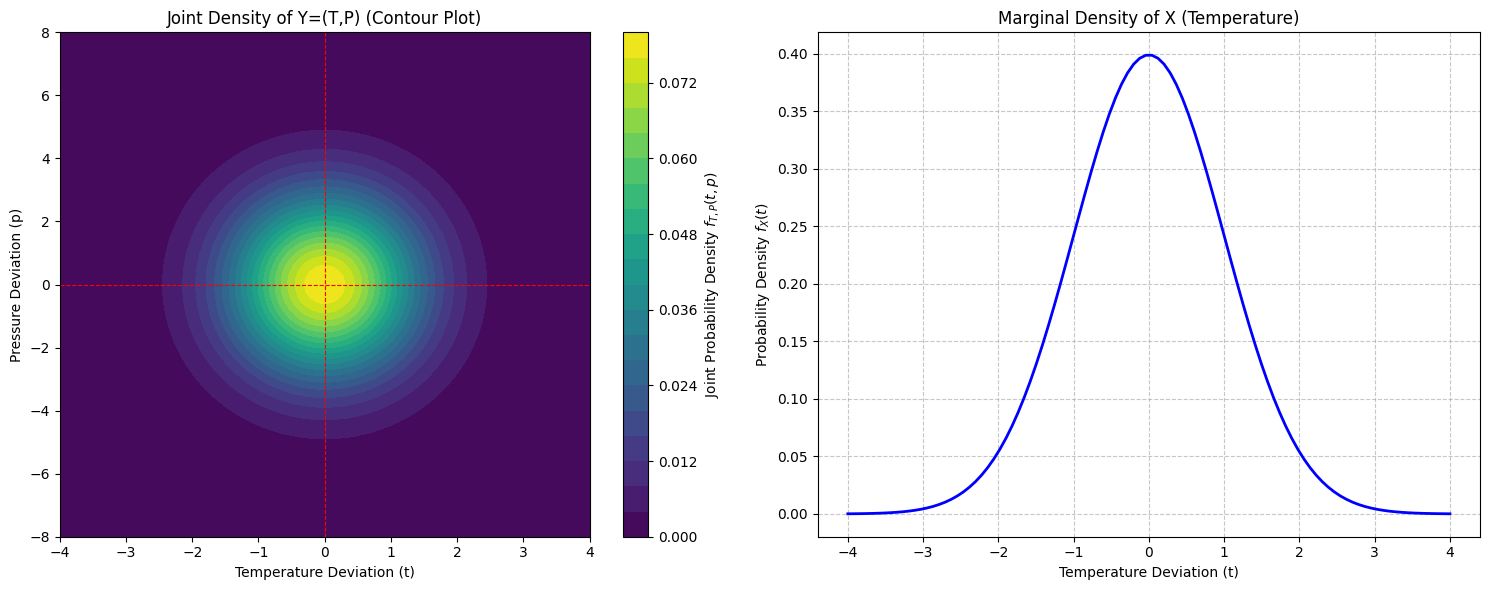

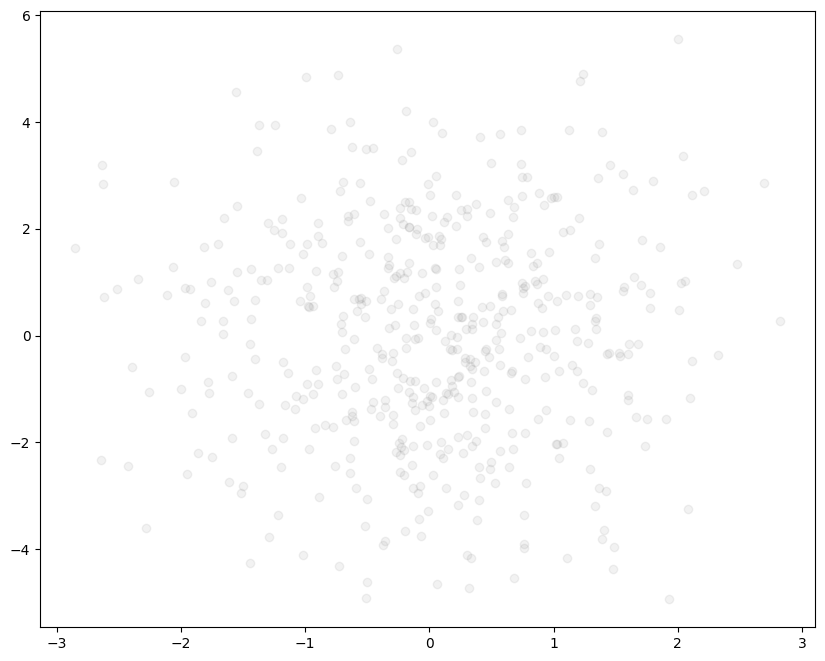

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, multivariate_normal

# Define parameters
mu_T = 0
sigma_T = 1
mu_P = 0
sigma_P = 2 # std dev from variance 4

# 1. Joint density of Y=(T,P) as a contour plot or heat map

x_vals = np.linspace(-4, 4, 100)
y_vals = np.linspace(-8, 8, 100)
X, Y = np.meshgrid(x_vals, y_vals)

# Calculate the joint PDF manually or using multivariate_normal
# f_T(t) = norm.pdf(X, loc=mu_T, scale=sigma_T)
# f_P(p) = norm.pdf(Y, loc=mu_P, scale=sigma_P)
# Z = f_T(t) * f_P(p) # Due to independence

# Using multivariate_normal for (T,P)
mean_vec = [mu_T, mu_P]
cov_mat = [[sigma_T**2, 0], [0, sigma_P**2]] # Covariance matrix for independent variables

pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

rv = multivariate_normal(mean_vec, cov_mat)
Z = rv.pdf(pos)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(label='Joint Probability Density $f_{T,P}(t,p)$')
plt.xlabel('Temperature Deviation (t)')
plt.ylabel('Pressure Deviation (p)')
plt.title('Joint Density of Y=(T,P) (Contour Plot)')
plt.axvline(0, color='r', linestyle='--', linewidth=0.8)
plt.axhline(0, color='r', linestyle='--', linewidth=0.8)

# 2. Marginal density of X (T)
plt.subplot(1, 2, 2)
plt.plot(x_vals, norm.pdf(x_vals, loc=mu_T, scale=sigma_T), color='blue', linewidth=2)
plt.xlabel('Temperature Deviation (t)')
plt.ylabel('Probability Density $f_X(t)$')
plt.title('Marginal Density of X (Temperature)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Diagram illustrating that sigma(X) is coarser than sigma(Y)

plt.figure(figsize=(10, 8))
# Create a dummy scatter plot to represent the R^2 space
plt.scatter(np.random.normal(mu_T, sigma_T, 500), np.random.normal(mu_P, sigma_P, 500), alpha=0.1, color='gray')

# Draw some

vertical strips

In [ ]:
# for sigma(X) events
plt.axvline(x=-1, color='red', linestyle='--', label='Boundary of a $\sigma(X)$ event (e.g., $X \in (-\infty, -1]$)')
plt.axvline(x=1, color='red', linestyle='--')

# Draw some

horizontal strips

In [ ]:
# which are NOT in sigma(X) but are in sigma(Y)
plt.axhline(y=-3, color='blue', linestyle=':', label='Boundary of a $\sigma(Y)$ event that is not in $\sigma(X)$ (e.g., $P \in [-3, 3]$)')
plt.axhline(y=3, color='blue', linestyle=':')

plt.xlabel('Temperature Deviation (t)')
plt.ylabel('Pressure Deviation (p)')
plt.title('Conceptual Diagram: $\sigma(X)$ vs $\sigma(Y)$')
plt.text(-3.5, 6, '$\sigma(X)$ events are vertical strips', color='red')
plt.text(-3.5, -6, '$\sigma(Y)$ events can be any region, including horizontal strips or arbitrary shapes', color='blue')
plt.xlim(-4, 4)
plt.ylim(-8, 8)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 13. Compute the differential entropy of $X$

For a normal distribution $N(\mu, \sigma^2)$, the differential entropy is given by the formula:
$$ h(X) = \frac{1}{2} \log_e(2\pi e \sigma^2) $$

Here, $X \sim N(0,1)$, so $\mu = 0$ and $\sigma^2 = 1$.

Therefore, $h(X) = \frac{1}{2} \log_e(2\pi e \cdot 1) = \frac{1}{2} \log_e(2\pi e)$.

In [ ]:
import math

# Parameters for X ~ N(0, 1)
sigma_X_squared = 1

h_X = 0.5 * math.log(2 * math.pi * math.e * sigma_X_squared)
print(f"Differential Entropy h(X): {h_X:.4f}")

### 14. Compute the differential entropy of $Y$

The random variable $Y = (T,P)$ is a 2-dimensional Gaussian random vector. Since $T$ and $P$ are independent, the covariance matrix $\Sigma$ is diagonal:
$$ \Sigma = \begin{pmatrix} \sigma_T^2 & 0 \\ 0 & \sigma_P^2 \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 4 \end{pmatrix} $$

For an $n$-dimensional multivariate normal distribution, the differential entropy is given by:
$$ h(Y) = \frac{1}{2} \log_e((2\pi e)^n |\Sigma|) $$
where $n=2$ and $|\Sigma|$ is the determinant of the covariance matrix.

$|\Sigma| = (1)(4) - (0)(0) = 4$.

So, $h(Y) = \frac{1}{2} \log_e((2\pi e)^2 \cdot 4) = \frac{1}{2} [\log_e((2\pi e)^2) + \log_e(4)] = \frac{1}{2} [2 \log_e(2\pi e) + \log_e(4)] = \log_e(2\pi e) + \frac{1}{2} \log_e(4)$.

Alternatively, for independent random variables, the joint entropy is the sum of the individual entropies:
$$ h(Y) = h(T) + h(P) $$
We know $h(T) = h(X) = \frac{1}{2} \log_e(2\pi e \cdot 1)$.
For $P \sim N(0,4)$, $\sigma_P^2 = 4$, so $h(P) = \frac{1}{2} \log_e(2\pi e \cdot 4)$.

So, $h(Y) = \frac{1}{2} \log_e(2\pi e) + \frac{1}{2} \log_e(2\pi e \cdot 4)$.

In [ ]:
# Parameters for Y=(T,P)
sigma_T_squared = 1
sigma_P_squared = 4

# Using the sum of individual entropies (due to independence)
h_T = 0.5 * math.log(2 * math.pi * math.e * sigma_T_squared)
h_P = 0.5 * math.log(2 * math.pi * math.e * sigma_P_squared)

h_Y = h_T + h_P
print(f"Differential Entropy h(Y): {h_Y:.4f}")

# Verify using the multivariate formula
det_cov = sigma_T_squared * sigma_P_squared
h_Y_multivariate = 0.5 * math.log((2 * math.pi * math.e)**2 * det_cov)
print(f"Differential Entropy h(Y) (multivariate formula): {h_Y_multivariate:.4f}")

### 15. Compute the conditional differential entropy $h(Y|X)$, and interpret it physically

The conditional differential entropy $h(Y|X)$ measures the uncertainty remaining in $Y$ after observing $X$. For independent random variables, the mutual information $I(X;Y) = 0$. In this case, $Y=(T,P)$ and $X=T$. So $Y$ is a vector where one component is $X$.

The formula for conditional entropy is $h(Y|X) = h(Y) - I(X;Y)$.

We can also view $Y$ as $(X, P)$. So, $h(Y|X) = h((X,P)|X)$. This simplifies to the entropy of $P$ conditioned on $X$. Since $X$ (which is $T$) and $P$ are independent, conditioning on $X$ provides no information about $P$. Thus:

$$ h(Y|X) = h(P) = \frac{1}{2} \log_e(2\pi e \sigma_P^2) $$

Here, $\sigma_P^2 = 4$.

**Physical Interpretation:**

$h(Y|X)$ represents the remaining uncertainty about the full sensor state $(T,P)$ after we have already measured and known the temperature deviation ($T$). Since $T$ and $P$ are independent, knowing $T$ does not reduce our uncertainty about $P$. Therefore, the uncertainty remaining about $Y=(T,P)$ after knowing $X=T$ is simply the uncertainty of the pressure component, $P$. It tells us how much 'new' information about the overall system state (temperature and pressure) is gained by measuring pressure, once temperature is already known.

In [ ]:
# Parameters for P ~ N(0, 4)
sigma_P_squared = 4

h_P = 0.5 * math.log(2 * math.pi * math.e * sigma_P_squared)

# As derived, h(Y|X) = h(P) due to independence of T and P
h_Y_given_X = h_P

print(f"Conditional Differential Entropy h(Y|X): {h_Y_given_X:.4f}")

### 16. Discuss what happens to $h(X|Y)$ in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other

The conditional differential entropy $h(X|Y)$ measures the uncertainty remaining in $X$ after observing $Y$. In this model, $X(t,p) = t$ and $Y(t,p) = (t,p)$. If we know $Y=(t,p)$, then we know $X$ exactly, as $X$ is simply the first component of $Y$. Thus, there should be no uncertainty remaining about $X$.

In the discrete case, if one random variable $X$ is completely determined by another random variable $Y$, then the conditional entropy $H(X|Y)$ is 0. This is because $P(X=x|Y=y)$ would be 1 for a specific $x$ and 0 for all other $x$, meaning $\log_2(P(X=x|Y=y))$ would be $-\infty$ for $P=0$ and $0$ for $P=1$, and the sum would resolve to 0.

However, in the continuous case, when $X$ is completely determined by $Y$, the conditional differential entropy $h(X|Y)$ is typically $-\infty$. This is a common property of continuous random variables that are functionally dependent. The reason lies in the nature of probability densities. If $X=g(Y)$ for some function $g$, then given $Y=y$, $X$ takes on the exact value $g(y)$ with probability 1. The "density" at this single point is infinite, which leads to $-\infty$ in the entropy calculation when dealing with the logarithm of a density. The differential entropy is sensitive to the scale and 'spread' of the distribution, and a degenerate distribution (a point mass) has infinite density at that point, making its entropy $-\infty$.

So, while $h(X|Y)$ being $-\infty$ mathematically signifies a complete lack of uncertainty, it highlights a crucial difference between how entropy is defined and behaves for discrete versus continuous random variables in scenarios of functional dependence.

#Q11) Conditional Expectation

A bank monitors credit-card transactions for possible fraud.

For each transaction, let the sample space be

$$
\Omega=\{\omega_1,\omega_2,\omega_3,\omega_4\},
$$

where:

* $\omega_1$: low-risk customer, legitimate transaction,
* $\omega_2$: low-risk customer, fraudulent transaction,
* $\omega_3$: high-risk customer, legitimate transaction,
* $\omega_4$: high-risk customer, fraudulent transaction.

Assume the probabilities are

$$
P(\{\omega_1\})=0.50,\qquad
P(\{\omega_2\})=0.10,\qquad
P(\{\omega_3\})=0.20,\qquad
P(\{\omega_4\})=0.20.
$$

Let $X:\Omega\to\mathbb R$ denote the fraud indicator:

$$
X(\omega_1)=0,\qquad
X(\omega_2)=1,\qquad
X(\omega_3)=0,\qquad
X(\omega_4)=1.
$$

Thus $X=1$ means the transaction is fraudulent, and $X=0$ means it is legitimate.

Now suppose the bank does not observe the full outcome $\omega$, but only the customer’s risk class. Define $Y:\Omega\to\mathbb R$ by

$$
Y(\omega_1)=0,\qquad
Y(\omega_2)=0,\qquad
Y(\omega_3)=1,\qquad
Y(\omega_4)=1.
$$

Thus:

* $Y=0$ means “low-risk customer,”
* $Y=1$ means “high-risk customer.”

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

3. Explain why $E[X\mid Y]$ must be $\sigma(Y)$-measurable, and therefore must be constant on the sets ${ \omega_1,\omega_2}$ and ${\omega_3,\omega_4}$.

4. Compute $E[X\mid Y]$ explicitly.

5. Verify the defining property of conditional expectation by checking that for every set $A\in\sigma(Y)$,

$$
\int_A E[X\mid Y]\,dP=\int_A X\,dP.
$$

6. Compute $E[X]$ and compare it with $E[X\mid Y]$.

7. Interpret $E[X\mid Y]$ in practical terms. What does it tell the bank?

8. Let

$$
\mathfrak G=\mathfrak P(\Omega).
$$

Compute $E[X\mid \mathfrak G]$ and compare it with $E[X\mid Y]$.

9. Explain how this example shows that conditional expectation is the “best estimate of $X$ using only the information contained in $Y$.”